# Logistic Regression Models

### `imports` and `data`

In [10]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import statsmodels.api as sm

datasets = {
    "All Features": ("../data/X_train.csv", "../data/X_test.csv"),
    "Independent Clusters": ("../data/X_train_cluster_independent.csv", "../data/X_test_cluster_independent.csv"),
    "Agglomerated Clusters": ("../data/X_train_cluster_agglom.csv", "../data/X_test_cluster_agglom.csv")
}

y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

### With all data imported, we can create all 3 models in one shot using a for loop, and then store them in `results`

Optimization terminated successfully.
         Current function value: 0.509263
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.509403
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.544582
         Iterations 6


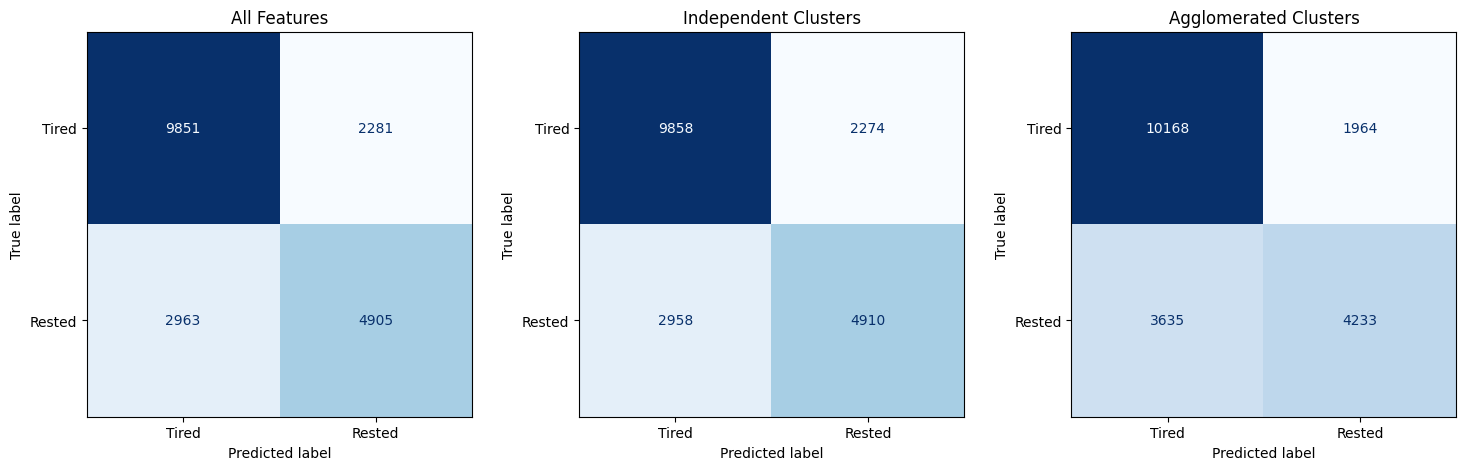

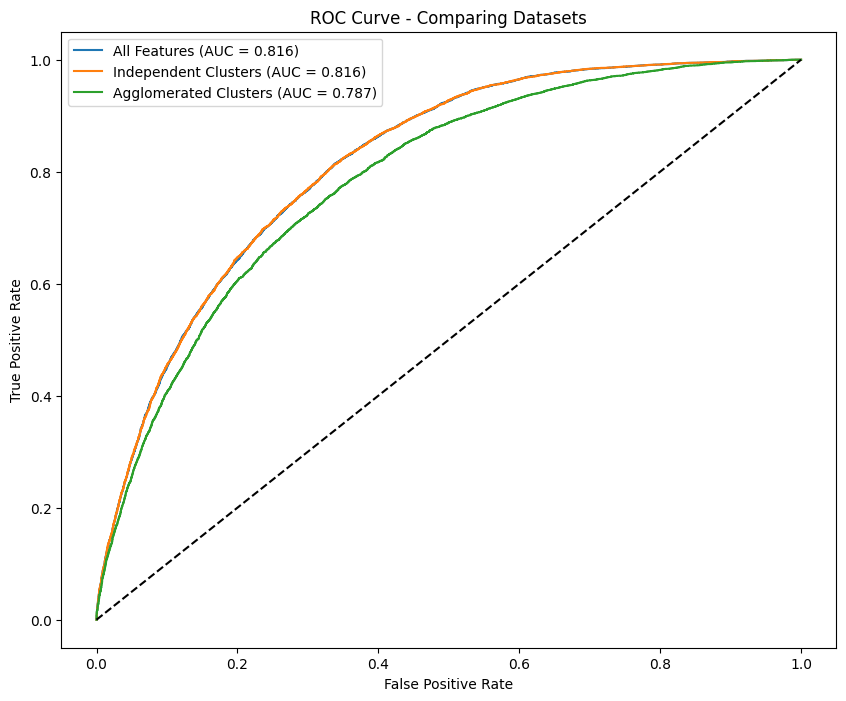

------------- Model Comparison Summary -------------
                      Feature Count AUC-ROC Misclassification Rate
All Features                     64  81.59%                 26.22%
Independent Clusters             35  81.61%                 26.16%
Agglomerated Clusters            12  78.68%                 28.00%


In [26]:
results = {}

# format confusion matrix plots
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
index_cm = 0

# format ROC graph
fig_roc = plt.figure(figsize=(10, 8))

for name, (train_data_path, test_data_path) in datasets.items():
    
    # building model
    X_train = pd.read_csv(train_data_path)
    X_test = pd.read_csv(test_data_path)

    X_train_sm = sm.add_constant(X_train)
    X_test_sm = sm.add_constant(X_test)

    model = sm.Logit(y_train, X_train_sm).fit()

    # predictions and metrics next, then storage
    y_probability = model.predict(X_test_sm)
    y_predicted = (y_probability > 0.5).astype(int)
    area_under_curve = sk.metrics.roc_auc_score(y_test, y_probability)
    accuracy = sk.metrics.accuracy_score(y_test, y_predicted)
    misclassification = 1 - accuracy

    results[name] = {
        "AUC-ROC": f"{area_under_curve:.2%}",
        "Misclassification Rate": f"{misclassification:.2%}",
        "Feature Count": X_train.shape[1],
        "Model": model
    }

    # plotting curve, summarize data
    false_positive_rate, true_positive_rate, _ = sk.metrics.roc_curve(y_test, y_probability)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC = {area_under_curve:.3f})")

    #print(model.summary())

    # confusion matrix
    confusion_matrix = sk.metrics.confusion_matrix(y_test, y_predicted)
    display_cm = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Tired", "Rested"])
    display_cm.plot(ax=axes_cm[index_cm], cmap='Blues', colorbar=False, values_format='d')
    axes_cm[index_cm].set_title(f"{name}")
    index_cm += 1
    

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Comparing Datasets')
plt.legend()
plt.show()

# results
comparison_df = pd.DataFrame(results).T[['Feature Count', 'AUC-ROC', 'Misclassification Rate']]
print("----------------- Model Comparison Summary -------------")
print(comparison_df)

### Here we have a interesting obervation: The all features model and independent features cluster model performed almost identically! This means that the junk cleaning we did when clustering was actually really good and accurate. We see in agglomeration our AUC score goes down about 0.03, which is more or less expected given "the price of simplification".

### (Next can discuss what we're observing in coeff's.)

### (Currently using previous code as reference material)

Optimization terminated successfully.
         Current function value: 0.544582
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            felt_rested   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79987
Method:                           MLE   Df Model:                           12
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.1853
Time:                        11:53:28   Log-Likelihood:                -43567.
converged:                       True   LL-Null:                       -53475.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.5874      0.009    -68.539      0.000   

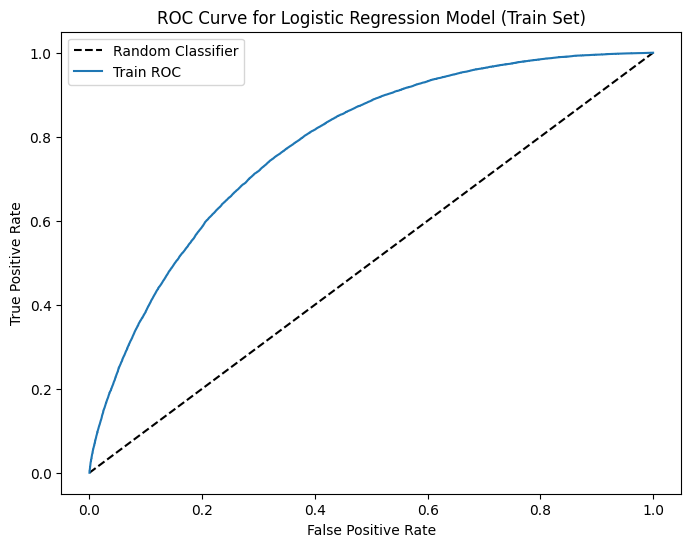

In [12]:
x_train = pd.read_csv("../data/X_train_cluster_agglom.csv")
y_train = pd.read_csv("../data/y_train.csv")
x_test = pd.read_csv("../data/X_test_cluster_agglom.csv")
y_test = pd.read_csv("../data/y_test.csv")

# Drop columns with low importance based on previous analysis (optional)

drop_cols = []

x_train = x_train.drop(columns=drop_cols)

x_test = x_test.drop(columns=drop_cols)

# Fit logistic regression model

model = sm.Logit(y_train, sm.add_constant(x_train)).fit()

#Show all coefficients and p-values

print(model.summary())

# Evaluate model performance on training and test sets

conf_matrix_train = sk.metrics.confusion_matrix(y_train, model.predict(sm.add_constant(x_train)) > 0.5)

misclassify_rate_train = (conf_matrix_train[0][1] + conf_matrix_train[1][0]) / len(y_train)

print(f"Misclassification Rate: {misclassify_rate_train:.2%}")

auc_roc_train = sk.metrics.roc_auc_score(y_train, model.predict(sm.add_constant(x_train)))
print(f"AUC-ROC: {auc_roc_train:.2%}")

conf_matrix_test = sk.metrics.confusion_matrix(y_test, model.predict(sm.add_constant(x_test)) > 0.5)

misclassify_rate_test = (conf_matrix_test[0][1] + conf_matrix_test[1][0]) / len(y_test)

print(f"Misclassification Rate: {misclassify_rate_test:.2%}")

auc_roc_test = sk.metrics.roc_auc_score(y_test, model.predict(sm.add_constant(x_test)))
print(f"AUC-ROC: {auc_roc_test:.2%}")

# Plot ROC curve for training set

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
fpr_train, tpr_train, _ = sk.metrics.roc_curve(y_train, model.predict(sm.add_constant(x_train)))
plt.plot(fpr_train, tpr_train, label="Train ROC")
plt.title("ROC Curve for Logistic Regression Model (Train Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
